In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

C:\Users\Lena\Promotion\neurolib\GUI\current\gui\data\01100
01100


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 4
limit = 40
i_range = range(0, limit,i_stepsize)
i_range_0 = range(0, limit,i_stepsize)
i_range_1 = range(0, limit,i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.40000000000000013
-------  12 0.47500000000000014 0.42500000000000016
-------  16 0.47500000000000014 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003


In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  0 , total integrated cost =  13602.2666253313
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  12 0.47500000000000014 0.4250000000000001

In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.2666253313
Gradient descend method:  None
RUN  1 , total integrated cost =  1569.550805949199
RUN  2 , total integrated cost =  800.2171466906979
RUN  3 , total integrated cost =  458.32054963073267
RUN  4 , total integrated cost =  283.9109461462548
RUN  5 , total integrated cost =  187.65783354422723
RUN  6 , total integrated cost =  131.19692442714532
RUN  7 , total integrated cost =  98.31810952063569
RUN  8 , total integrated cost =  74.33612679349807
RUN  9 , total integrated cost =  59.7009286452497
RUN  10 , total integrated cost =  46.83193980677544
RUN  11 , total integrated cost =  40.138955298645314
RUN  12 , total integrated cost =  32.75873821062775
RUN  13 , total integrated cost =  29.2750725276465
RUN  14 , total integrated cost =  27.34587268769735
RUN  15 , total 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  803 , total integrated cost =  2.0388528385033866
Improved over  803  iterations in  765.4982544  seconds by  99.98501093314326  percent.
Problem in initial value trasfer:  Vmean_exc -56.67605722808333 -56.6760572166647
weight =  66715.29385767734
set cost params:  1.0 66715.29385767734 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13580.397029098442
Gradient descend method:  None
RUN  1 , total integrated cost =  12008.685884970868
RUN  2 , total integrated cost =  11992.170268961288
RUN  3 , total integrated cost =  11980.987971349638
RUN  4 , total integrated cost =  11914.776141032595
RUN  5 , total integrated cost =  11889.932851069203
RUN  6 , total integrated cost =  11886.690349618884
RUN  7 , total integrated cost =  11827.123005592166
RUN  8 , total integrated cost =  11749.080182405864
RUN  9 , total integrated cost =  11747.48533975801
RUN  10 , total integrated cost =  11747.168251706902
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  11631.105945600515
Improved over  22  iterations in  3.1746537000000217  seconds by  14.353712040386  percent.
Problem in initial value trasfer:  Vmean_exc -56.67551112272404 -56.67552533432533
-------  8 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  752.9227888844955
RUN  2 , total integrated cost =  496.3658570002084
RUN  3 , total integrated cost =  298.3556098776615
RUN  4 , total integrated cost =  185.46156387654472
RUN  5 , total integrated cost =  116.71126818570788
RUN  6 , total integrated cost =  79.62911802591869
RUN  7 , total integrated cost =  57.56474107634281
RUN  8 , total integrated cost =  39.161493858189964
RUN  9 , total integrated cost =  30.06604681228033
RUN  10 , total integrated cost =  24.06344965759822
RUN  11 , 

...

RUN  1 , total integrated cost =  16568.215943541192
Control only changes marginally.
RUN  1 , total integrated cost =  16568.215943541192
Improved over  1  iterations in  0.36391709999998056  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.54971134254949 -71.54994920045249
-------  36 0.4250000000000001 0.5500000000000003
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7741.667733280556
Gradient descend method:  None
RUN  1 , total integrated cost =  7741.6677332803165


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  7741.6677332803165
Control only changes marginally.
RUN  2 , total integrated cost =  7741.6677332803165
Improved over  2  iterations in  0.38451549999990675  seconds by  3.083755473198835e-12  percent.
Problem in initial value trasfer:  Vmean_exc -77.76263567676612 -77.76263573397324
weight =  10.000000000000309
set cost params:  1.0 10.000000000000309 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7741.6677332803165
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7741.6677332803165
Control only changes marginally.
RUN  1 , total integrated cost =  7741.6677332803165
Improved over  1  iterations in  0.2651789000001372  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -77.76263567676612 -77.76263573397324


--------- 0
--------- 4
--------- 8
--------- 12
--------- 16
--------- 20
--------- 24


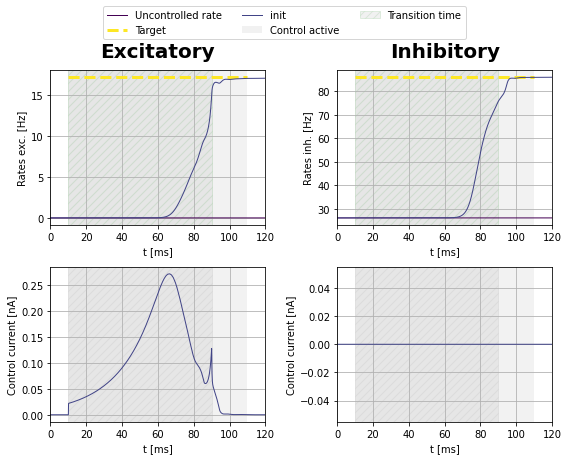

--------- 28
--------- 32
--------- 36


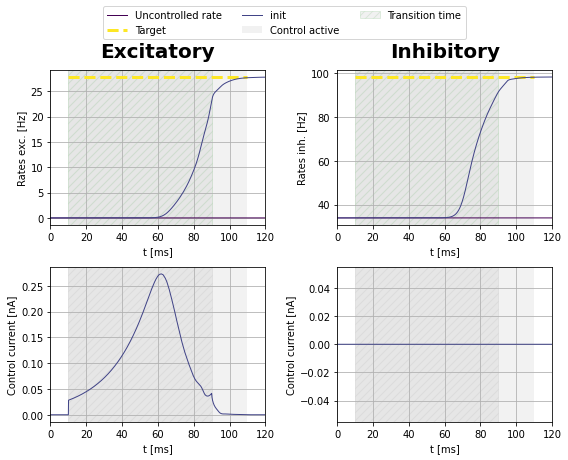

In [33]:

#plot initial guesses
for i in i_range:
    print("---------", i)
    
    if i not in [24,36]:
        continue
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [32]:
found_solution = []
no_solution = []
factor_iteration = 10.
factor_rescale = 1.7
already_tried = [ [] for _ in range(len(exc)) ]

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break


    for i in i_range:
        print("------- ", i, exc[i], inh[i])        

        if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.2 * np.abs(
            np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
            np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.2 * np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
            bestState_init[i][0,0,:]) < target[i][0,0,-1] + 1. and np.amax(
            bestState_init[i][0,1,:]) < target[i][0,1,-1] + 1.:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        if len(found_solution) == 0:
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_, already_tried[i])

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if closest_ != -1:
            control0 = factor_rescale *  bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
        
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
    break

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  4 0.4500000000000001 0.3750000000000001
found solution for  4
-------  8 0.47500000000000014 0.40000000000000013
found solution for  8
-------  12 0.47500000000000014 0.42500000000000016
found solution for  12
-------  16 0.47500000000000014 0.4500000000000002
found solution for  16
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  24 0.4000000000000001 0.5000000000000002
[0, 4, 8, 12, 16, 20] []
closest index  20 []
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1462.0480596774319
Gradient descend method:  None
RUN  1 , total integrated cost =  221.46717224027893
RUN  2 , total integrated cost =  213.51735071059298
RUN 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  79 , total integrated cost =  212.9270929286602
Improved over  79  iterations in  10.451038900000185  seconds by  85.43638209980335  percent.
Problem in initial value trasfer:  Vmean_exc -56.652018783978846 -56.652019035713536
weight =  140.00010949251762
set cost params:  1.0 140.00010949251762 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2977.632105406391
Gradient descend method:  None
RUN  1 , total integrated cost =  2976.2175979376507
RUN  2 , total integrated cost =  2976.2098116914326
RUN  3 , total integrated cost =  2976.193022027584
RUN  4 , total integrated cost =  2976.009021035178
RUN  5 , total integrated cost =  2975.9572188919146
RUN  6 , total integrated cost =  2975.9519882563936
RUN  7 , total integrated cost =  2975.9322772366413
RUN  8 , total integrated cost =  2975.771649198874
RUN  9 , total integrated cost =  2975.7364862406807
RUN  10 , total integrated cost =  2975.732330082644
RUN  11 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  48 , total integrated cost =  2974.183845662014
Improved over  48  iterations in  5.489670299999943  seconds by  0.11580543271669796  percent.
Problem in initial value trasfer:  Vmean_exc -56.65430454281017 -56.654307753660696
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  32 0.47500000000000014 0.5250000000000002
found solution for  32
-------  36 0.4250000000000001 0.5500000000000003
[0, 4, 8, 12, 16, 20, 28, 32] []
closest index  32 []
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  745.0997943861951
Gradient descend method:  None
RUN  1 , total integrated cost =  293.378583270045
RUN  2 , total integrated cost =  226.7097382060652
RUN  3 , total integrated cost =  222.1166888799389
RUN  4 , total integrated cost =  218.53267146760837
RUN  5 , total integrated cost =  217.80905772306716
RUN  6 , total integrated cost =  217.68882245571

ERROR:root:Problem in initial value trasfer


RUN  171 , total integrated cost =  213.91655669852761
Improved over  171  iterations in  18.97600109999985  seconds by  71.29021396727808  percent.
Problem in initial value trasfer:  Vmean_exc -56.63612307916926 -56.63612300336012
weight =  361.9012877152319
set cost params:  1.0 361.9012877152319 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7736.946956419922
Gradient descend method:  None
RUN  1 , total integrated cost =  7704.811702966187
RUN  2 , total integrated cost =  7704.709688260865
RUN  3 , total integrated cost =  7704.682676955112
RUN  4 , total integrated cost =  7704.648838117017
RUN  5 , total integrated cost =  7704.403559155454
RUN  6 , total integrated cost =  7701.188250289138
RUN  7 , total integrated cost =  7700.570724213269
RUN  8 , total integrated cost =  7700.543328340703
RUN  9 , total integrated cost =  7700.537402674567
RUN  10 , total integrated cost =  7700.534549775954
RUN  11 , total integrated cost =  7700.531950073051
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  37 , total integrated cost =  7696.724125445594
Improved over  37  iterations in  3.416186899999957  seconds by  0.5198798854495408  percent.
Problem in initial value trasfer:  Vmean_exc -56.635571949352126 -56.63557643411975


In [34]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print("------------------------------------------------")
    print('-------------------------', counter)
    
    if counter > 20:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_init[i] == [True, True]:
            continue
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
                       
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
    counter += 1

------------------------------------------------
------------------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  6591.536342784053
set cost params:  1.0 6591.536342784053 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.511162751322
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.511162751322
Control only changes marginally.
RUN  1 , total integrated cost =  5901.511162751322
Improved over  1  iterations in  0.2626301999998759  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6265416046941 -56.62654408453016
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  78444.87464511849
set cost params:  1.0 78444.87464511849 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.093228493199
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13602.093228493199
Control only changes marginally.
RUN  1 , total integrated cost =  13602.093228493199
Improved over  1  iterations in  0.31409290000010515  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67542045497192 -56.67543702682732
converged for  4
-------  8 0.47500000000000014 0.40000000000000013
weight =  201552.5409097657
set cost params:  1.0 201552.5409097657 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.060743681628
Gradient descend method:  None


...

RUN  1 , total integrated cost =  2959.7373925561888
Control only changes marginally.
RUN  1 , total integrated cost =  2959.7373925561888
Improved over  1  iterations in  0.392543200000091  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.654304542816675 -56.65430775366721
converged for  24
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
weight =  363.0184960711968
set cost params:  1.0 363.0184960711968 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7720.400495992245
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7720.400495992245
Control only changes marginally.
RUN  1 , total integrated cost =  7720.400495992245
Improved over  1  iterations in  0.2749135999997634  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.635570103946314 -56.63557461176037
no convergence
------------------------------------------------
------------------------- 8
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7720.400495992245
Control only changes marginally.
RUN  1 , total integrated cost =  7720.400495992245
Improved over  1  iterations in  0.3739206000000195  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.635570103946314 -56.63557461176037
converged for  36
------------------------------------------------
------------------------- 9
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence


In [35]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [38]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  18038.591355646022
set cost params:  1.0 18038.591355646022 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.079287432141
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5902.079287432141
Control only changes marginally.
RUN  1 , total integrated cost =  5902.079287432141
Improved over  1  iterations in  0.8985519000002569  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.626056302399085 -56.626055688774144
converged for  0
-------  4 0.4500000000000001 0.3750000000000001
weight =  159255.21354976573
set cost params:  1.0 159255.21354976573 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13392.584959159098
Gradient descend method:  None
RUN  1 , total integrated cost =  13316.072142356617
RUN  2 , total integrated cost =  13315.954518820248
RUN  3 , total integrated cost =  13315.952190120324
RUN  4 , total integrated cost =  13315.952161071868
RUN  5 , total integrated cost =  13315.952160322428
RUN  6 , total integrated cost =  13315.952160304618
RUN  7 , total integrated cost =  13315.952160303932
RUN  8 , total integrated cost =  13315.952160303874
RUN  9 , tota

ERROR:root:Problem in initial value trasfer


Problem in initial value trasfer:  Vmean_exc -56.675470617446294 -56.675485965899774
no convergence
-------  8 0.47500000000000014 0.40000000000000013
weight =  340702.55594495643
set cost params:  1.0 340702.55594495643 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17357.344748205593
Gradient descend method:  None
RUN  1 , total integrated cost =  17299.537062767704
RUN  2 , total integrated cost =  17299.377539348417
RUN  3 , total integrated cost =  17299.377170709344
RUN  4 , total integrated cost =  17299.37716535454
RUN  5 , total integrated cost =  17299.377165338796
RUN  6 , total integrated cost =  17299.377165338163
RUN  7 , total integrated cost =  17299.37716533808
RUN  8 , total integrated cost =  17299.377165338065
State only changes marginally.
RUN  9 , total integrated cost =  17299.377165338057
State only changes marginally.


...

RUN  1 , total integrated cost =  17339.83140418995
Control only changes marginally.
RUN  1 , total integrated cost =  17339.83140418995
Improved over  1  iterations in  0.612702100000206  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.688430323633725 -56.68843284430445
no convergence
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
weight =  10732.546436867638
set cost params:  1.0 10732.546436867638 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21311.107129512042
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21311.107129512042
Control only changes marginally.
RUN  1 , total integrated cost =  21311.107129512042
Improved over  1  iterations in  0.6026154999999562  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69783003442448 -56.69783077048776
converged for  28
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
--------------- 11
[[True, True], [True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.350000000

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  17339.83140418995
Control only changes marginally.
RUN  1 , total integrated cost =  17339.83140418995
Improved over  1  iterations in  0.893182999999226  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.688430323633725 -56.68843284430445
converged for  16
-------  20 0.4500000000000001 0.4750000000000002
-------  24 0.4000000000000001 0.5000000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  32 0.47500000000000014 0.5250000000000002
-------  36 0.4250000000000001 0.5500000000000003
--------------- 12
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True,

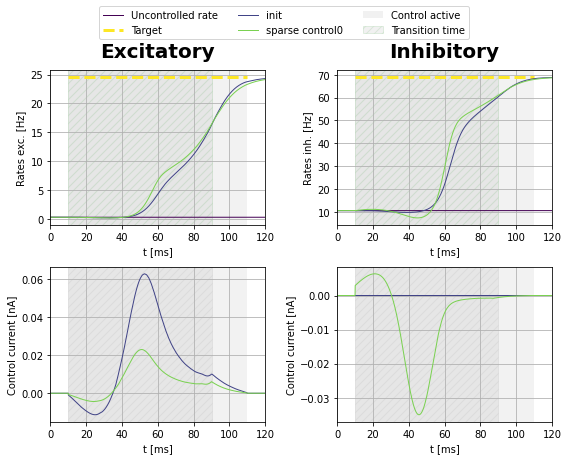

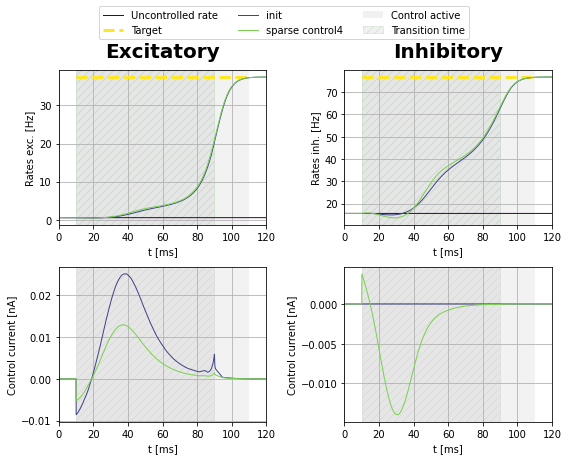

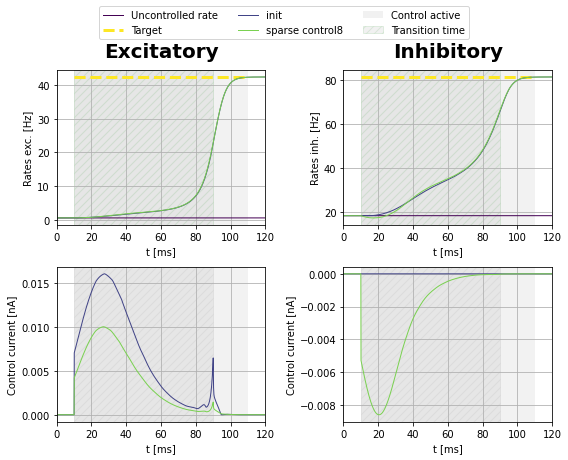

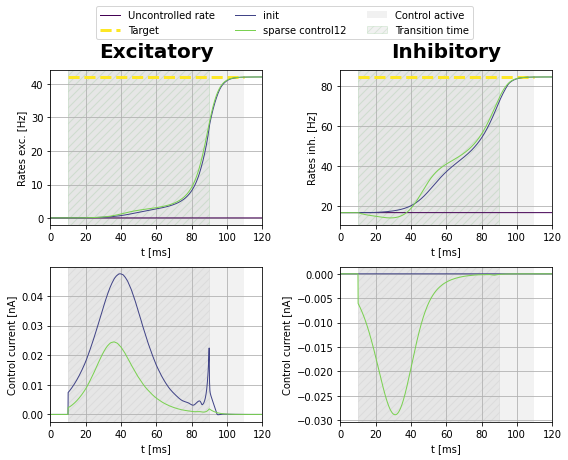

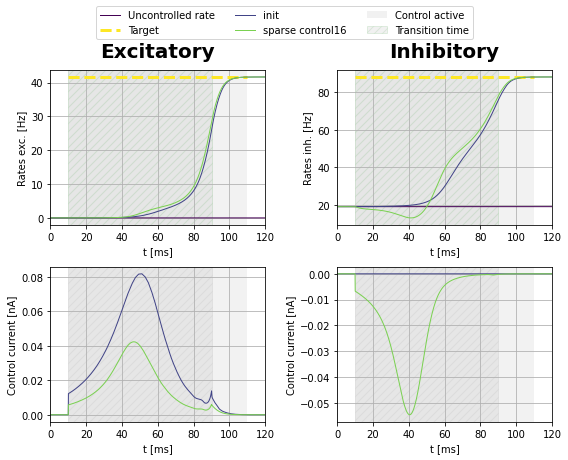

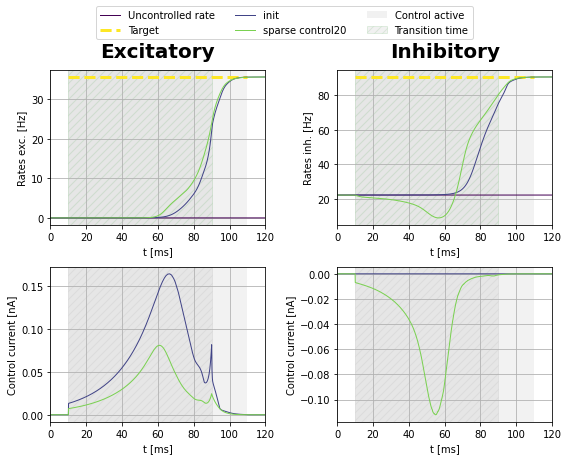

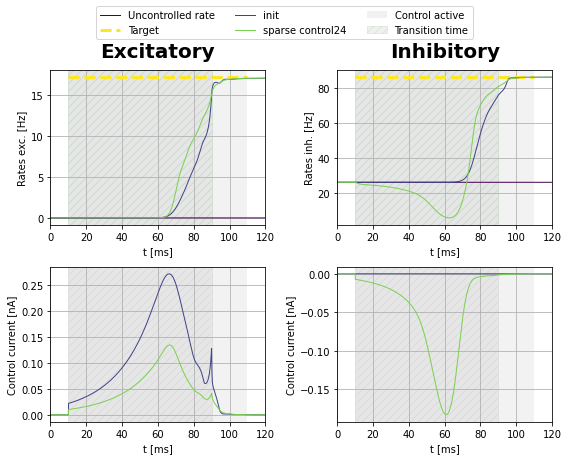

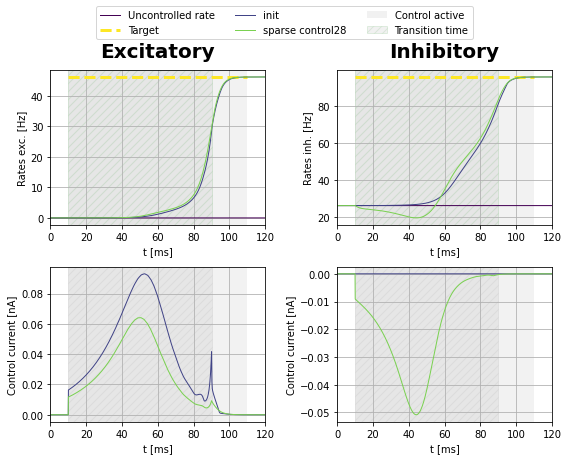

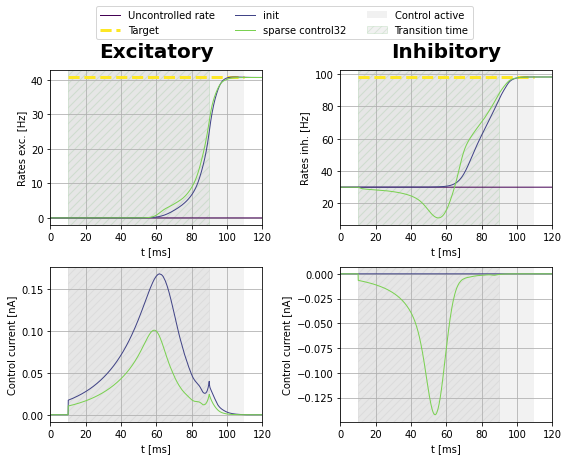

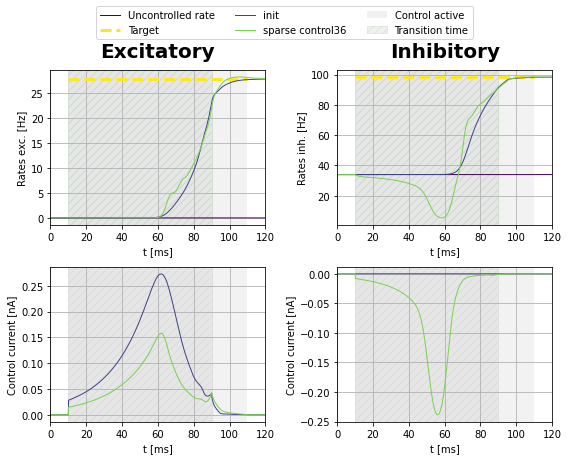

In [39]:

for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)


In [40]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [41]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3653759086440997
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3653759086440997
Control only changes marginally.
RUN  1 , total integrated cost =  0.3653759086440997
Improved over  1  iterations in  0.21128719999978784  seconds by  0.0  percent.
converged for  0
------

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  284 , total integrated cost =  0.059972945525463256
Improved over  284  iterations in  30.47071439999945  seconds by  99.98802318933413  percent.
Problem in initial value trasfer:  Vmean_exc -56.6906650223288 -56.690665046354
no convergence
-------  12 0.47500000000000014 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  210.63307383742236
Gradient descend method:  None
RUN  1 , total integrated cost =  0.41767052541549554
RUN  2 , total integrated cost =  0.3915865818276301
RUN  3 , total integrated cost =  0.3868920744257768
RUN  4 , total integrated cost =  0.3857217578205863
RUN  5 , total integrated cost =  0.3849124559462858
RUN  6 , total integrated cost =  0.38443932760092014
RUN  7 , total integrated cost =  0.38389253590966754
RUN  8 , total integrated cost =  0.3834737042113356
RUN  9 , total integrated cost =  0.38174710971162074
RUN  

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  3.9526837261318546
Control only changes marginally.
RUN  1 , total integrated cost =  3.9526837261318546
Improved over  1  iterations in  0.21710150000035355  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6690658545072 -56.66906587493467
converged for  20
-------  24 0.4000000000000001 0.5000000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.270145717678497
Gradient descend method:  None
RUN  1 , total integrated cost =  11.990947529308139
RUN  2 , total integrated cost =  11.977301937417037
RUN  3 , total integrated cost =  10.875310068596418
RUN  4 , total integrated cost =  10.84949570270289
RUN  5 , total integrated cost =  10.827689563470397
RUN  6 , total integrated cost =  10.806479519658325
RUN  7 , total integrated cost =  10.787970039989405
RUN  8 , total integrated cost =  10.771664276740776
RUN  9 , total integrated cost =  10.75278119150649
RUN 

...

RUN  1 , total integrated cost =  10.457680008798114
Control only changes marginally.
RUN  1 , total integrated cost =  10.457680008798114
Improved over  1  iterations in  0.29207120000046416  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.6518781095912 -56.651878035823486
converged for  24
-------  28 0.5000000000000002 0.5000000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.0491329387292687
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.0491329387292687
Control only changes marginally.
RUN  1 , total integrated cost =  2.0491329387292687
Improved over  1  iterations in  0.25521130000015546  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.697854228203845 -56.69785421324293
converged for  28
-------  32 0.47500000000000014 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.615617234289895
Gradient descend method:  None
RUN  1 , total integrated cost =  5.615617234289895
Control only changes marginally.
RUN  1 , total integrated cost =  5.615617234289895
Improved over  1  iterations in  0.348144599999614  seconds by  0.0  percent.
converged for  32
-------  36 0.4250000000000001 0.5500000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.355953184913165
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  13.355953184913165
Control only changes marginally.
RUN  1 , total integrated cost =  13.355953184913165
Improved over  1  iterations in  0.22416059999977733  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.636116918809144 -56.636116939400985
converged for  36
--------------- 3
[[True, True], [True, True], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
-------  4 0.4500000000000001 0.3750000000000001
-------  8 0.47500000000000014 0.400000000

----------- 0


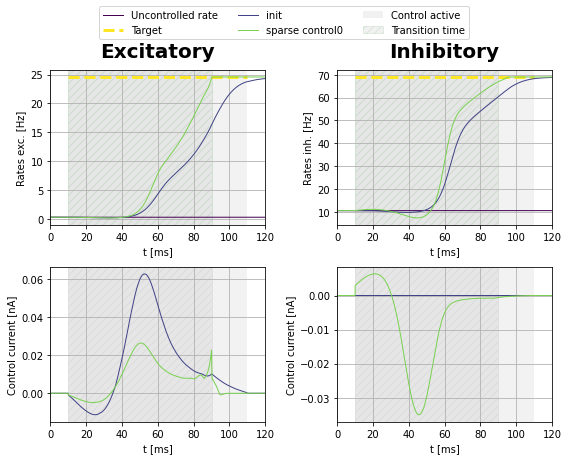

----------- 4


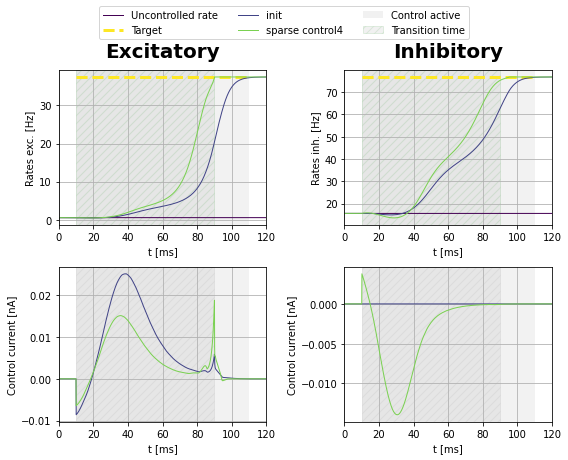

----------- 8


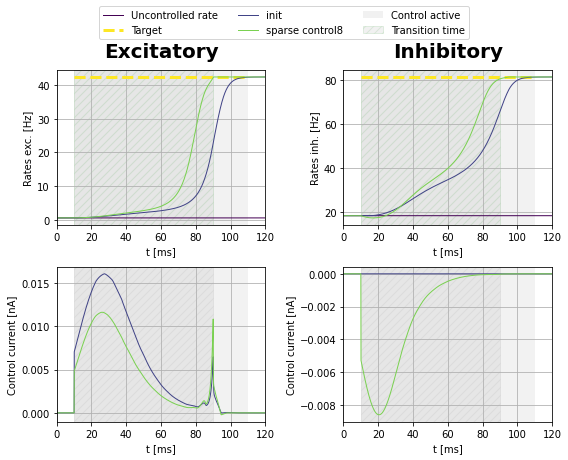

----------- 12


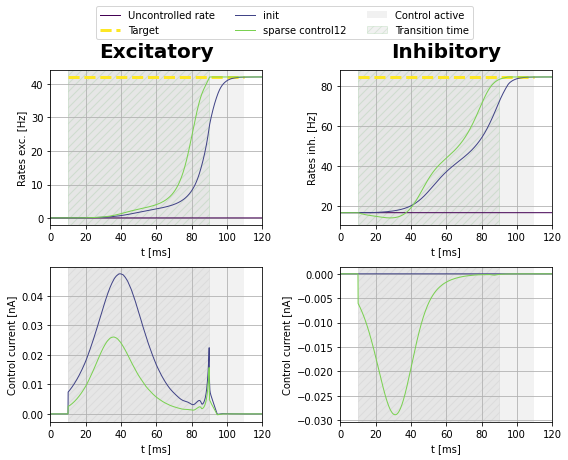

----------- 16


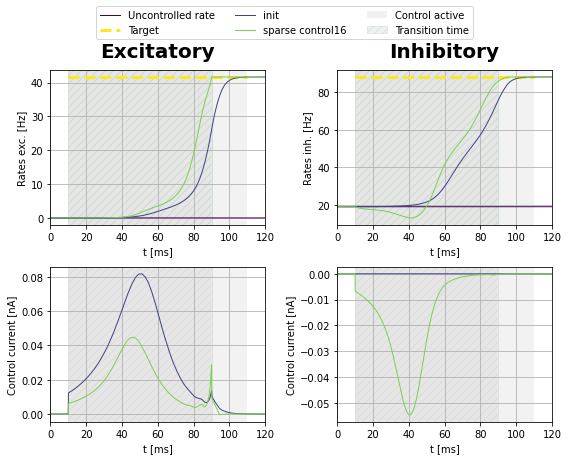

----------- 20


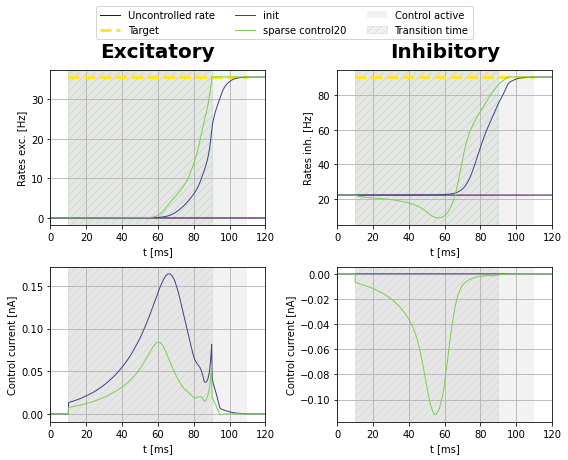

----------- 24


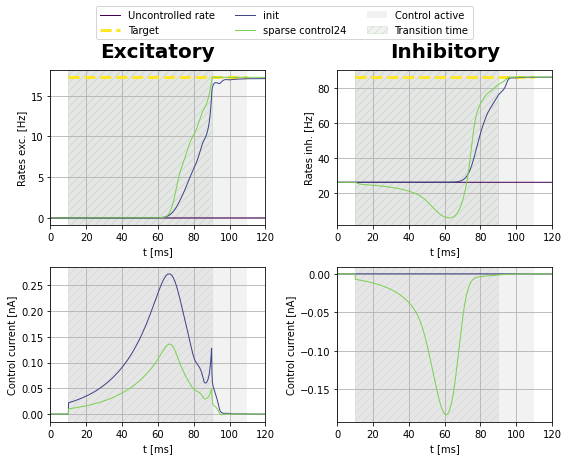

----------- 28


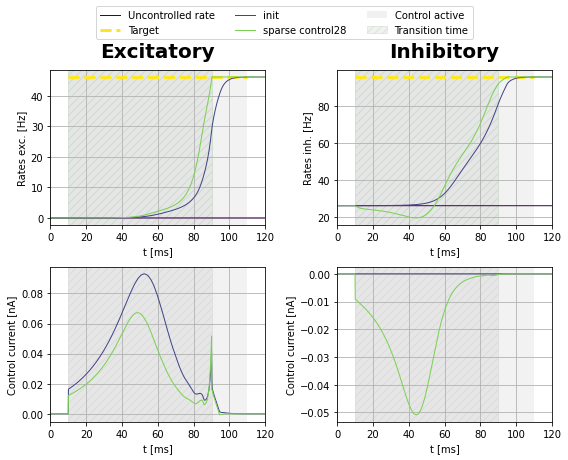

----------- 32


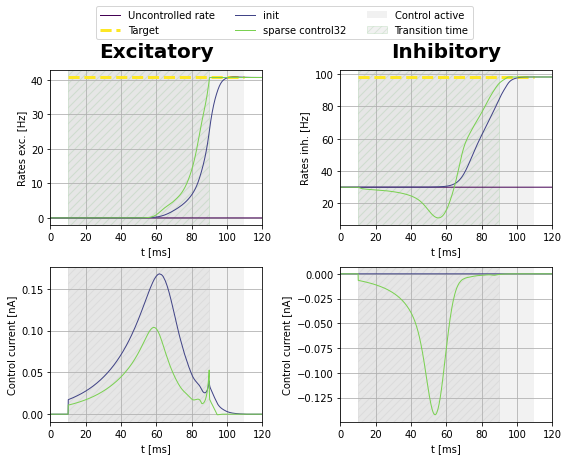

----------- 36


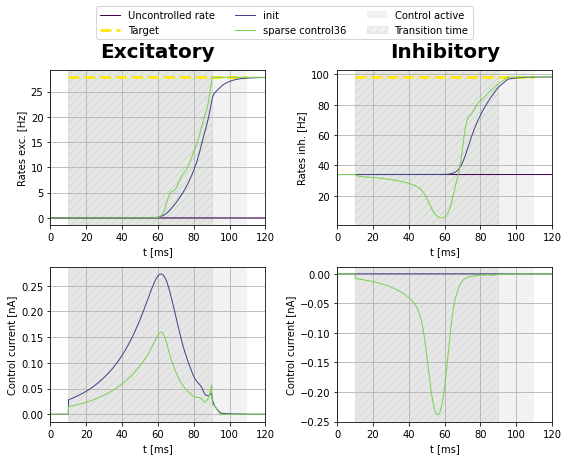

In [42]:
for i in i_range_1:
    
    print('-----------', i)
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_1[i]],
        [costnode_init[i], costnode_1[i]], [weights_init[i], weights_1[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()